# TP3


* Aballay, Cristian - SIU A2301
* Gianotti, Leandro - SIU D0161
* Mancini, Leonardo - SIU I0511

## Encontrar el logotipo de la gaseosa dentro de las imagenes provistas en *Material_TPs/TP3/images* a partir del template *Material_TPs/TP3/template*

* 1. (4 puntos) Obtener una deteccion del logo en cada imagen sin falsos positivos.
* 2. (4 puntos) Plantear y validar un algoritmo para multiples detecciones en la imagen *coca_multi.png* con el mismo template del item 1.
* 3. (2 puntos) Generalizar el algoritmo del item 2 para todas las imagenes.

Visualizar los resultados con bounding boxes en cada imagen mostrando el nivel de confianza de la deteccion.

In [35]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import supervision as sv

Lectura del template

In [36]:
template = cv.imread('template/pattern.png')
template_gray = cv.imread('template/pattern.png', cv.IMREAD_GRAYSCALE)
template_gray_inverted = cv.bitwise_not(template_gray)

# Analisis

## Analisis caracteristias locales

### SIFT

In [37]:
sift = cv.SIFT_create()
kp, descriptors = sift.detectAndCompute(template_gray, None)
# tambien existe la version que se ejecuta sobre GPU
# siendo acelerada por CUDA
# https://docs.opencv.org/3.4/df/db9/classcv_1_1cuda_1_1Feature2DAsync.html#a56c6c75e25e9616934c25552164a363c

# Verificamos cuántas características encontró
print(f'Cantidad y dimension de los descriptores: {descriptors.shape}')
print(f'-- 1er keypoint -- ')
print(f'Orientacion: {kp[0].angle}')
print(f'Octava donde se encontro: {kp[0].octave}')
print(f'Posicion en la imagen: {kp[0].pt}')
print(f'Descriptores: {len(descriptors)}')
print(f'Keypoints: {len(kp)}')

dir(kp[0])[-10:]
print(descriptors[0])

Cantidad y dimension de los descriptores: (211, 128)
-- 1er keypoint -- 
Orientacion: 205.7703857421875
Octava donde se encontro: 11928575
Posicion en la imagen: (20.96440315246582, 89.10887145996094)
Descriptores: 211
Keypoints: 211
[  2.   1.   2.   3.   4.   1.   0.   1. 126.  15.   0.   0.   3.   2.
   0.   1. 206.  42.   0.   0.   0.   0.   0.   0.  44.   3.   0.   0.
   0.   0.   0.   2.   8.   3.   1.   1.   3.   1.   0.   2. 145.   7.
   0.   0.   6.   2.   0.   2. 206.  23.   0.   0.   0.   0.   0.   2.
  73.   3.   0.   0.   0.   0.   1.   3.   2.   4.   1.   1.   6.   3.
   1.   1. 139.   8.   2.   0.   1.   1.   0.   6. 206.   4.   0.   0.
   0.   0.   0.  18.  77.   6.   0.   0.   0.   0.   0.   1.   1.   1.
   0.   0.   7.   6.   1.   0. 124.   3.   1.   1.   2.   2.   1.  14.
 206.   1.   0.   0.   0.   0.   0.  44.  50.   3.   0.   0.   0.   0.
   0.   5.]


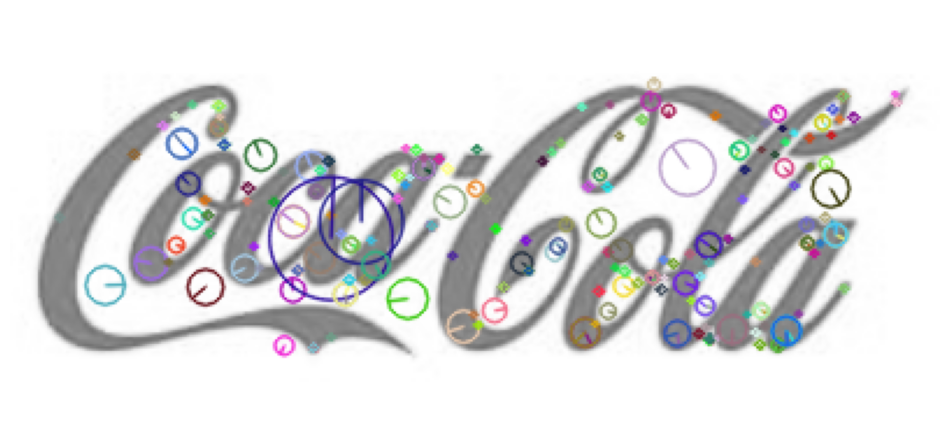

In [38]:
detalle = True
if detalle:
    # Dibujamos las características encontradas con más detalle
    template_2=cv.drawKeypoints(template_gray, kp, template_gray, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
else:
    # Dibujamos las características encontradas sin mucho detalle
    template_2=cv.drawKeypoints(template_gray, kp, template_gray)
    
sv.plot_image(template_2)

### Fast

Umbral: 10
nonmaxSuppression:True
Vecindario: 2
Keypoints totales con nonmaxSuppression: 405


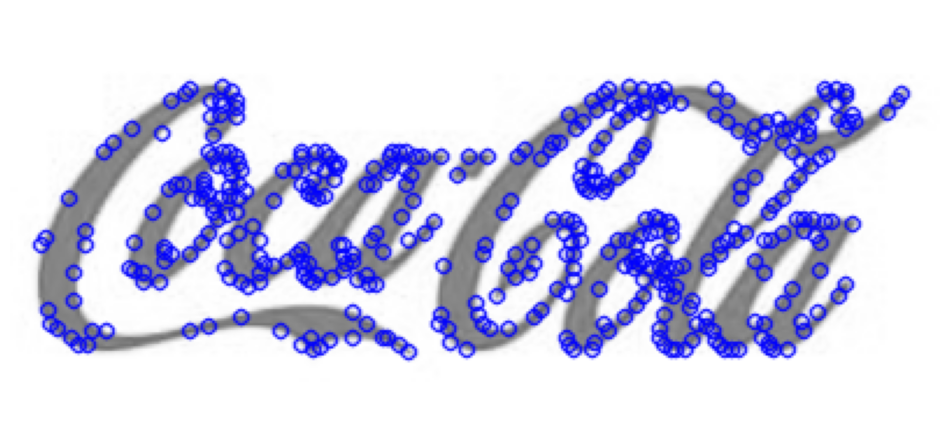

In [39]:
# Iniciamos el objeto FAST con valores por defecto
fast = cv.FastFeatureDetector_create()

# Encontramos y dibujamos los puntos clave (keypoints)
kp = fast.detect(template_gray, None)

# Devolvemos los valores por defecto
print( "Umbral: {}".format(fast.getThreshold()) )
print( "nonmaxSuppression:{}".format(fast.getNonmaxSuppression()) )
print( "Vecindario: {}".format(fast.getType()) )
print( "Keypoints totales con nonmaxSuppression: {}".format(len(kp)) )

# Graficamos
img2 = cv.drawKeypoints(template_gray, kp, None, color=(255,0,0))
sv.plot_image(img2)

### ORB

394


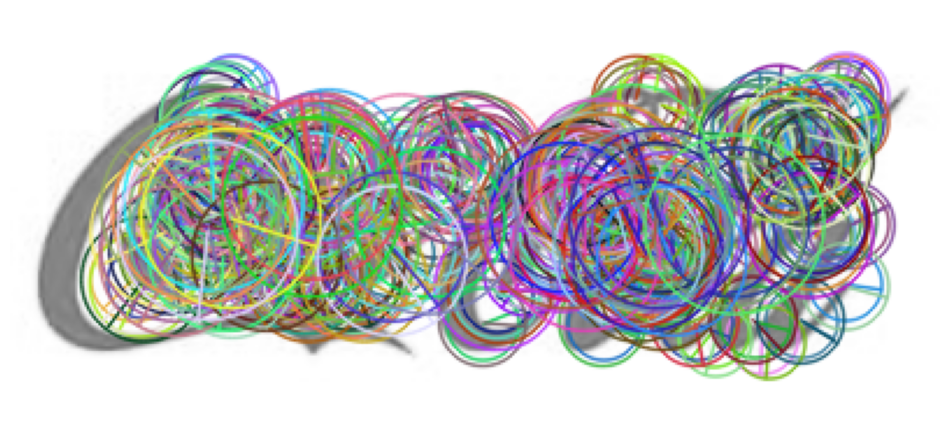

In [40]:
orb = cv.ORB_create()

# Encontramos los puntos clave (keypoints) - Es una versión de FAST
kp = orb.detect(template_gray, None)

# Calculamos los descriptores - Es una versión de BRIEF
kp, des = orb.compute(template_gray, kp)
# Verificamos cuántas características se encontraron
print(len(kp))

# Graficamos...
Detalle = True
if Detalle:
    # Dibujamos las características encontradas con más detalle
    img2=cv.drawKeypoints(template_gray,kp,template,flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
else:
    # Dibujamos las características encontradas sin mucho detalle
    img2=cv.drawKeypoints(template_gray,kp,template)
    
sv.plot_image(img2)

## Match Template

In [41]:
def resize_template(image, template):
    template_resized = template.copy()
    if image.shape[0] < template.shape[0] or image.shape[1] < template.shape[1]:
        scale_percent = (template.shape[0] * 100) / image.shape[0]  # percent of original size
        scale_percent = scale_percent if scale_percent < (template.shape[1] * 100) / image.shape[1] else (template.shape[1] * 100) / image.shape[1]  # percent of original size
        print(f"Resizing template to {scale_percent}%")
        width = int(template.shape[1] * scale_percent / 100)
        height = int(template.shape[0] * scale_percent / 100)
        dim = (width, height)
        template_resized = cv.resize(template, dim, interpolation = cv.INTER_AREA)
    return template_resized

In [42]:
def resize_template_piramidal(image, template):

    template_resized = template.copy()
    while image.shape[0] < template_resized.shape[0] or image.shape[1] < template_resized.shape[1]:
        template_resized = cv.pyrDown(template_resized)
        
    return template_resized

In [43]:
def matches_img(template, image, print_details=False):
    methods = ['cv.TM_CCOEFF', 'cv.TM_CCOEFF_NORMED', 'cv.TM_CCORR',
            'cv.TM_CCORR_NORMED', 'cv.TM_SQDIFF', 'cv.TM_SQDIFF_NORMED']
    images = []
    template_resized = resize_template_piramidal(image, template)
    w, h = template_resized.shape[::-1]
    for meth in methods:
        print_details and print(f"Method: {meth}")
        # Hago una copia de la imagen porque ciclo a ciclo le dibujo rectángulos
        img_salida = image.copy()
        
        method = eval(meth)
        
        # Aplicamos la coincidencia de patrones
        #--------------------------------------
        res = cv.matchTemplate(image, template_resized, method)
        print_details and print(f"Result shape: {res.shape}")
        # Encontramos los valores máximos y mínimos
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
        
        # Si el método es TM_SQDIFF o TM_SQDIFF_NORMED, tomamos el mínimo
        if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
            top_left = min_loc
        else:
            top_left = max_loc
        
        # Marcamos el lugar donde lo haya encontrado
        #----------------------------------------
        bottom_right = (top_left[0] + w, top_left[1] + h)
        cv.rectangle(img_salida,top_left, bottom_right, 255, 2)
        cropped_img = image[top_left[1]:top_left[1]+h, top_left[0]:top_left[0]+w]

        images.append(cropped_img)
        # Graficamos el procesamiento y la salida
        #----------------------------------------
        if print_details:
            plt.figure()

            plt.subplot(151)
            plt.imshow(image,cmap = 'gray')
            plt.title('Image')

            plt.subplot(152)
            plt.imshow(template,cmap = 'gray')
            plt.title('template')

            # Resultado de coincidencia
            plt.subplot(153)
            plt.imshow(res,cmap = 'gray')
            plt.title('Matching Result')
            
            # Imagen original con recuadros
            plt.subplot(154)
            plt.imshow(img_salida)
            plt.title('Detected Point')
            
            plt.subplot(155)
            plt.imshow(cropped_img, cmap='gray')
            plt.title('Imagen recortada')

            plt.suptitle(meth)
            plt.show()
    return template_resized, images

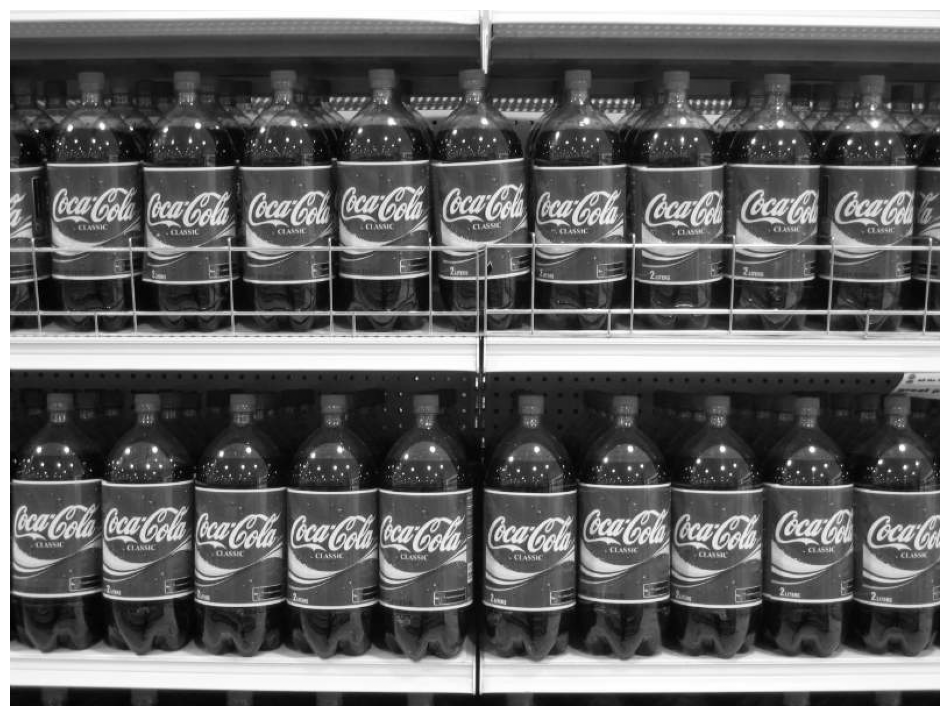

In [44]:
image_1 = cv.imread('imagenes/coca_multi.png')
img_rgb= cv.cvtColor(image_1, cv.COLOR_BGR2RGB)
image_gray = cv.cvtColor(image_1, cv.COLOR_BGR2GRAY)
sv.plot_image(image_gray)

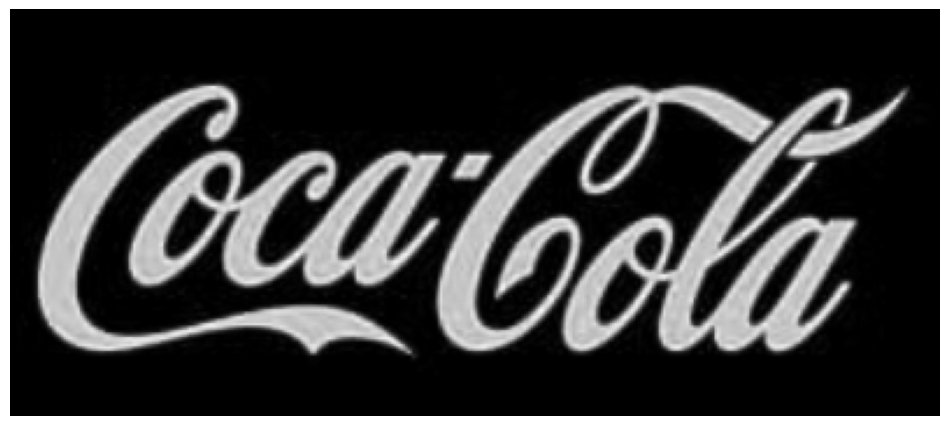

In [45]:
imagen_invertida = cv.bitwise_not(template_gray)
sv.plot_image(imagen_invertida)

Method: cv.TM_CCOEFF
Result shape: (424, 400)


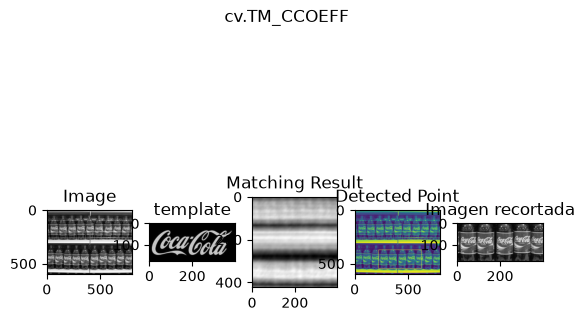

Method: cv.TM_CCOEFF_NORMED
Result shape: (424, 400)


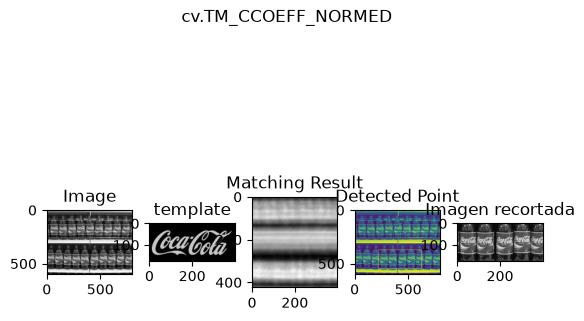

Method: cv.TM_CCORR
Result shape: (424, 400)


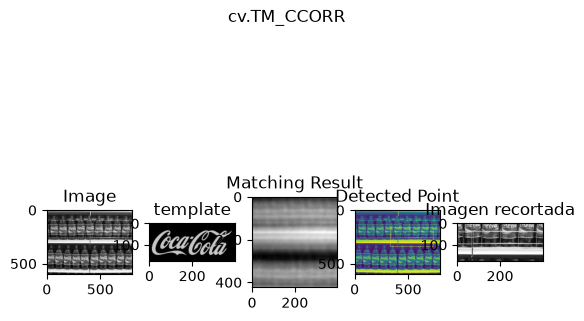

Method: cv.TM_CCORR_NORMED
Result shape: (424, 400)


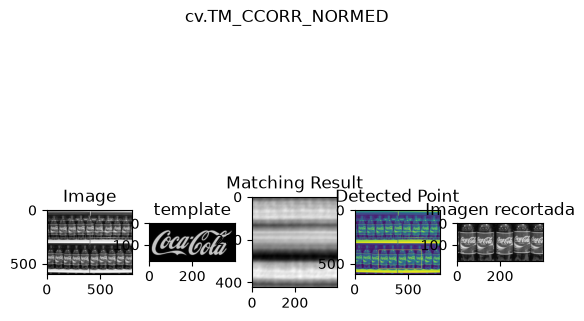

Method: cv.TM_SQDIFF
Result shape: (424, 400)


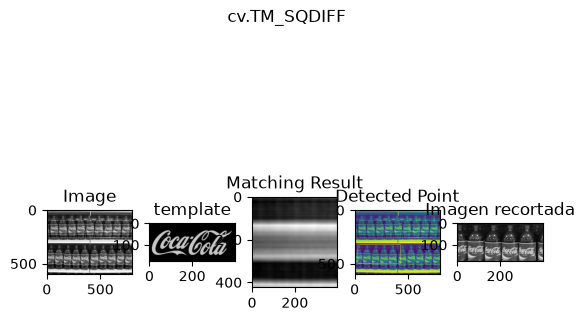

Method: cv.TM_SQDIFF_NORMED
Result shape: (424, 400)


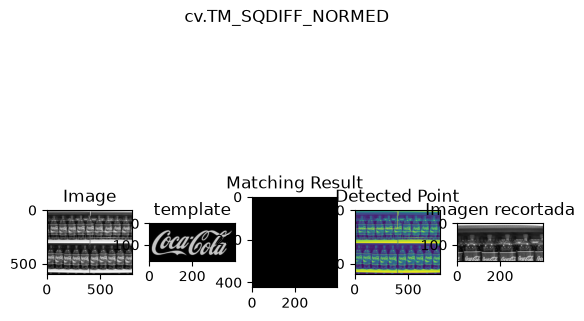

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(175, 400), dtype=uint8),
 [array([[28, 26, 21, ..., 51, 51, 50],
         [29, 27, 24, ..., 48, 49, 49],
         [29, 28, 26, ..., 48, 48, 48],
         ...,
         [51, 38, 26, ..., 74, 76, 77],
         [47, 40, 34, ..., 72, 76, 78],
         [30, 31, 33, ..., 71, 75, 79]], shape=(175, 400), dtype=uint8),
  array([[26, 21, 17, ..., 51, 50, 48],
         [27, 24, 20, ..., 49, 49, 49],
         [28, 26, 23, ..., 48, 48, 48],
         ...,
         [38, 26, 27, ..., 76, 77, 82],
         [40, 34, 35, ..., 76, 78, 83],
         [31, 33, 36, ..., 75, 79, 85]], shape=(175, 400), dtype=uint8),
  array([[100, 111, 103, ..., 146, 205, 232],
         [ 99, 105, 133, ..., 214, 232, 207],
         [103, 133, 213, ..., 211, 238, 159],
         ...,
         [ 34,  31,  30, ..., 

In [46]:
matches_img(imagen_invertida, image_gray, print_details=True)

## Correspondencia de Características (Match)

In [47]:
# Cargamos template de la máscara
template_gray = cv.imread('template/pattern.png', cv.IMREAD_GRAYSCALE)
template_gray_inverted = cv.bitwise_not(template_gray)
# Cargamos la imagen de búsqueda
img_gray_1 = cv.imread('imagenes/coca_retro_2.png', cv.IMREAD_GRAYSCALE)

### Orb

In [48]:
orb = cv.ORB_create(nfeatures=3000,       # Pide más puntos de los necesarios para asegurar captura
    scaleFactor=1.0,      # por defecto es 1.2. Esto crea niveles de pirámide más cercanos entre sí, ideal para imágenes pequeñas.
    nlevels=10,           # Incrementa los niveles de la pirámide de resolución.
    edgeThreshold=15,     # Reduce este valor (por defecto 31) para permitir que detecte puntos más cerca de los bordes físicos de la imagen pequeña.
    patchSize=15,         # Reduce el tamaño del parche para calcular el descriptor.
    scoreType=cv.ORB_FAST_SCORE)

# find the keypoints and descriptors with ORB
kp1_orb, des1_orb = orb.detectAndCompute(template_gray,None)
kp2_orb, des2_orb = orb.detectAndCompute(template_gray_inverted,None)
kp3_orb, des3_orb = orb.detectAndCompute(img_gray_1,None)

print(len(kp1_orb))
print(len(kp2_orb))
print(len(kp3_orb))

1539
1539
11007


### SIFT

In [49]:
sift = cv.SIFT_create(
    nfeatures=0,            # 0 significa ilimitado. Deja que detecte tantos como pueda.
    nOctaveLayers=3,        # Por defecto es 3. Puedes subirlo a 4 o 5 para buscar en sub-escalas más finas si el objeto es muy pequeño.
    contrastThreshold=0.03, # PARÁMETRO CRÍTICO: Por defecto es 0.04. Al bajarlo a 0.03 o 0.02, obligas a SIFT a aceptar puntos clave en zonas de bajo contraste.
    edgeThreshold=10,       # Por defecto es 10. Controla el filtro de estructuras tipo "línea". Si tus bordes están muy difusos, puedes subirlo a 15 para ser más permisivo.
    sigma=1.6               # Desenfoque gaussiano inicial. En baja resolución, un valor menor (ej. 1.2 o 1.4) evita que se pierda la poca nitidez existente.
)

# Y buscamos según el algoritmo...
kp1_sift, des1_sift = sift.detectAndCompute(template_gray,None)
kp2_sift, des2_sift = sift.detectAndCompute(template_gray_inverted,None)
kp3_sift, des3_sift = sift.detectAndCompute(img_gray_1,None)

print(len(kp1_sift))
print(len(kp2_sift))
print(len(kp3_sift))

211
211
1480


### Maches

In [50]:
def match_fuerza_bruta(template, image, alg, mask=None):
    kp1, des1 = alg.detectAndCompute(template,None)
    kp2, des2 = alg.detectAndCompute(image,mask)
    print(len(kp1))
    print(len(kp2))
    # create BFMatcher object
    bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
    print(des1.shape)
    print(des2.shape)
    # Match descriptors.
    matches = bf.match(des1,des2)

    # Sort them in the order of their distance.
    matches = sorted(matches, key = lambda x:x.distance)
    
    return matches, kp1, kp2

def match_fuerza_bruta_knn(template, image, alg, mask=None, percent=0.8):
    kp1, des1 = alg.detectAndCompute(template,None)
    kp2, des2 = alg.detectAndCompute(image,mask)
    print(len(kp1))
    print(len(kp2))
    # create BFMatcher object
    bf = cv.BFMatcher()

    # Match descriptors.
    matches = bf.knnMatch(des1,des2, k=2)
 
    good = []
    for m, n in matches:
        if m.distance < percent*n.distance:
            good.append(m)

    # Los ordenamos según distancia
    good = sorted(good, key = lambda x:x.distance)

    return good, kp1, kp2

def match_flann_knn(template, image, alg, mask=None, percent=0.8):
    kp1, des1 = alg.detectAndCompute(template,None)
    kp2, des2 = alg.detectAndCompute(image,mask)
    print(len(kp1))
    print(len(kp2))
    # FLANN parameters
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    search_params = dict(checks=50)   # or pass empty dictionary

    flann = cv.FlannBasedMatcher(index_params,search_params)
    print(des1.shape)
    print(des2.shape)
    matches = flann.knnMatch(des1,des2,k=2)

    good = []
    for m,n in matches:
        if m.distance < percent*n.distance:
            good.append(m)

    return good, kp1, kp2

In [51]:
def evaluate_matches(template, image, percent=0.8):
    print("--------------------------------")
    matches_1, kp1_1, kp2_1 = match_fuerza_bruta(template, image, orb)
    print(f"match_fuerza_bruta + orb: {len(matches_1)}")

    matches_3, kp1_3, kp2_3 = match_fuerza_bruta_knn(template, image, orb, percent=percent)
    print(f"match_fuerza_bruta_knn + orb: {len(matches_3)}")

    matches_4, kp1_4, kp2_4 = match_fuerza_bruta_knn(template, image, sift, percent=percent)
    print(f"match_fuerza_bruta_knn + sift: {len(matches_4)}")

    #matches_5, kp1_5, kp2_5 = match_flann_knn(template, image, orb, percent=percent)
    #print(f"Cantidad de coincidencias buenas: {len(matches_5)}")

    matches_6, kp1_6, kp2_6 = match_flann_knn(template, image, sift, percent=percent)
    print(f"match_flann_knn + sift: {len(matches_6)}")
    print("--------------------------------")


In [52]:
def preparar_imagen_baja_resolucion(image):

    # Aumentar tamaño (por ejemplo, al doble 2x) usando interpolación Lanczos
    img_grande = cv.resize(image, (0, 0), fx=2.0, fy=2.0, interpolation=cv.INTER_LANCZOS4)
    
    # Aplicar CLAHE para resaltar texturas y bordes difusos
    clahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    img_contrastada = clahe.apply(img_grande)
    
    return img_contrastada

In [53]:
image_gray_2 = preparar_imagen_baja_resolucion(img_gray_1)

In [54]:
evaluate_matches(template_gray_inverted, img_gray_1, percent=0.9)
evaluate_matches(template_gray, img_gray_1, percent=0.9)
evaluate_matches(template_gray_inverted, image_gray_2, percent=0.9)

--------------------------------
1539
11007
(1539, 32)
(11007, 32)
match_fuerza_bruta + orb: 73
1539
11007
match_fuerza_bruta_knn + orb: 0
211
1480
match_fuerza_bruta_knn + sift: 65
211
1480
(211, 128)
(1480, 128)
match_flann_knn + sift: 67
--------------------------------
--------------------------------
1539
11007
(1539, 32)
(11007, 32)
match_fuerza_bruta + orb: 59
1539
11007
match_fuerza_bruta_knn + orb: 0
211
1480
match_fuerza_bruta_knn + sift: 43
211
1480
(211, 128)
(1480, 128)
match_flann_knn + sift: 46
--------------------------------
--------------------------------
1539
32436
(1539, 32)
(32436, 32)
match_fuerza_bruta + orb: 99
1539
32436
match_fuerza_bruta_knn + orb: 0
211
5142
match_fuerza_bruta_knn + sift: 72
211
5142
(211, 128)
(5142, 128)
match_flann_knn + sift: 78
--------------------------------


211
5142
(211, 128)
(5142, 128)


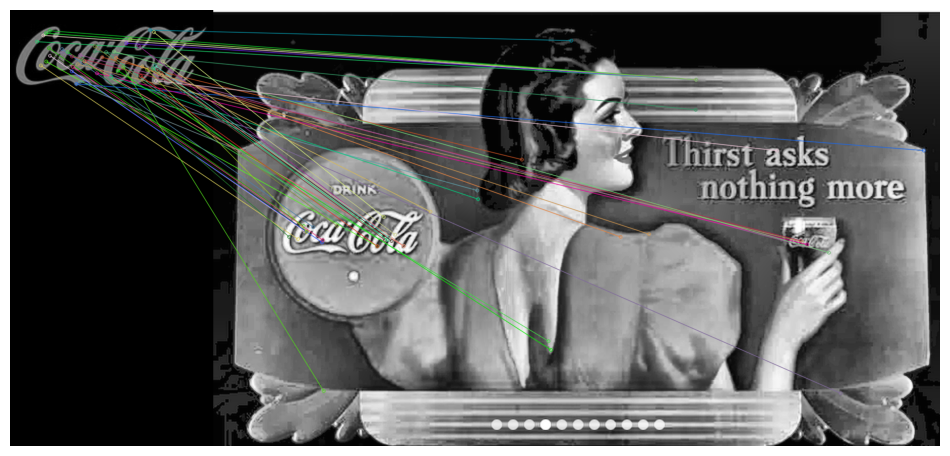

In [55]:
#matches_1, kp1_1, kp2_1 = match_fuerza_bruta(template_gray_inverted, img_gray_1, orb)
matches_1, kp1_1, kp2_1 = match_flann_knn(template_gray_inverted, image_gray_2, sift, percent=0.90)
#matches_1, kp1_1, kp2_1 = match_fuerza_bruta(template_gray_inverted, img_gray_1, orb, percent=0.9)
# Dibujamos las primeras N coincidencias (las mejores)
N = 50
# cv.drawMatchesKnn espera una lista de listas como coincidencias
img3 = cv.drawMatchesKnn(template_gray_inverted, kp1_1, image_gray_2, kp2_1, [matches_1[:N]], None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
#img3 = cv.drawMatchesKnn(img1,kp1,img2,kp2,good,None,flags=cv.DrawMatchesFlags_DEFAULT)
sv.plot_image(img3)

### FLANN (Fast Library for Approximate Nearest Neighbors)

### FLANN + Homografía

In [56]:
MIN_MATCH_COUNT = 8
def draw_matches_with_homography(template, img, kp1, kp2, good, min_match_count=MIN_MATCH_COUNT):
    
    if len(good) > min_match_count:
        src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
        dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
        matchesMask = mask.ravel().tolist()
        h,w = template.shape
        pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
        dst = cv.perspectiveTransform(pts, M)
        img_2 = cv.polylines(img, [np.int32(dst)], True, 255, 3, cv.LINE_AA)
    else:
        print( "No se encontraron suficientes coincidencias - {}/{}".format(len(good), min_match_count) )
        matchesMask = None

    print(f"Cantidad de coincidencias buenas: {len(matchesMask)}")
    draw_params = dict(matchColor = (0,255,0), # dibujar coincidencias en verde
                    singlePointColor = None,
                    matchesMask = matchesMask, # dibujar solo inliers
                    flags = 2)

    img3 = cv.drawMatches(template, kp1, img_2, kp2, good, None, **draw_params)
    sv.plot_image(img3)

Cantidad de coincidencias buenas: 88


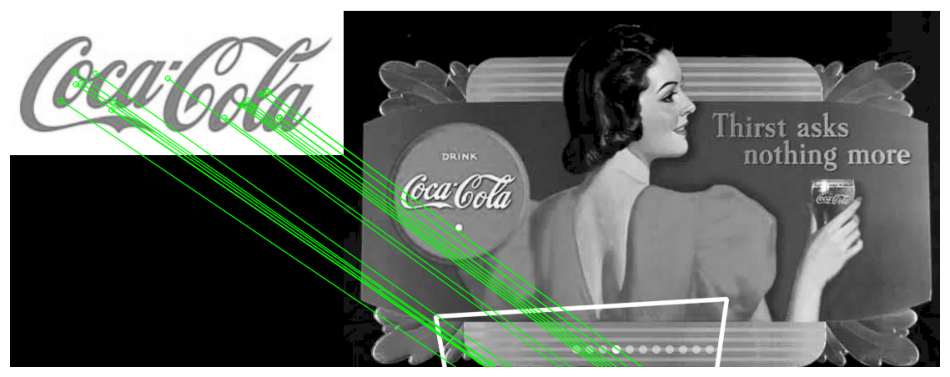

In [57]:
draw_matches_with_homography(template_gray, img_gray_1, kp1_1, kp2_1, matches_1)

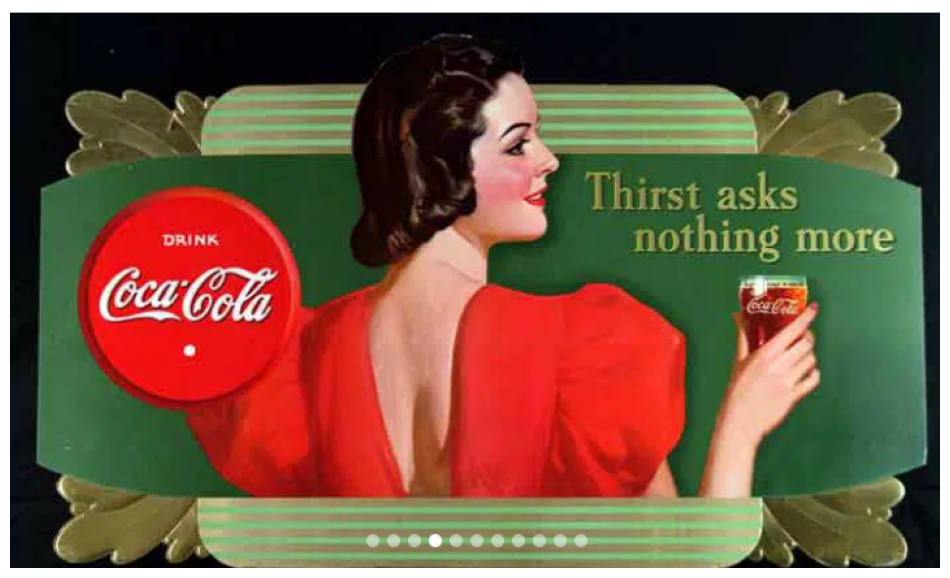

In [58]:
img_seg = cv.imread('imagenes/coca_retro_2.png')
sv.plot_image(img_seg)

# 1. (4 puntos) Obtener una deteccion del logo en cada imagen sin falsos positivos.
Testeamos todas las imagenes

Procesando imagen: coca_logo_1.png
211
342
(211, 128)
(342, 128)
211
342
(211, 128)
(342, 128)
Cantidad de coincidencias buenas: 21
Cantidad de coincidencias buenas: 50
Usando template invertido para la imagen: coca_logo_1.png
Cantidad de coincidencias buenas: 50


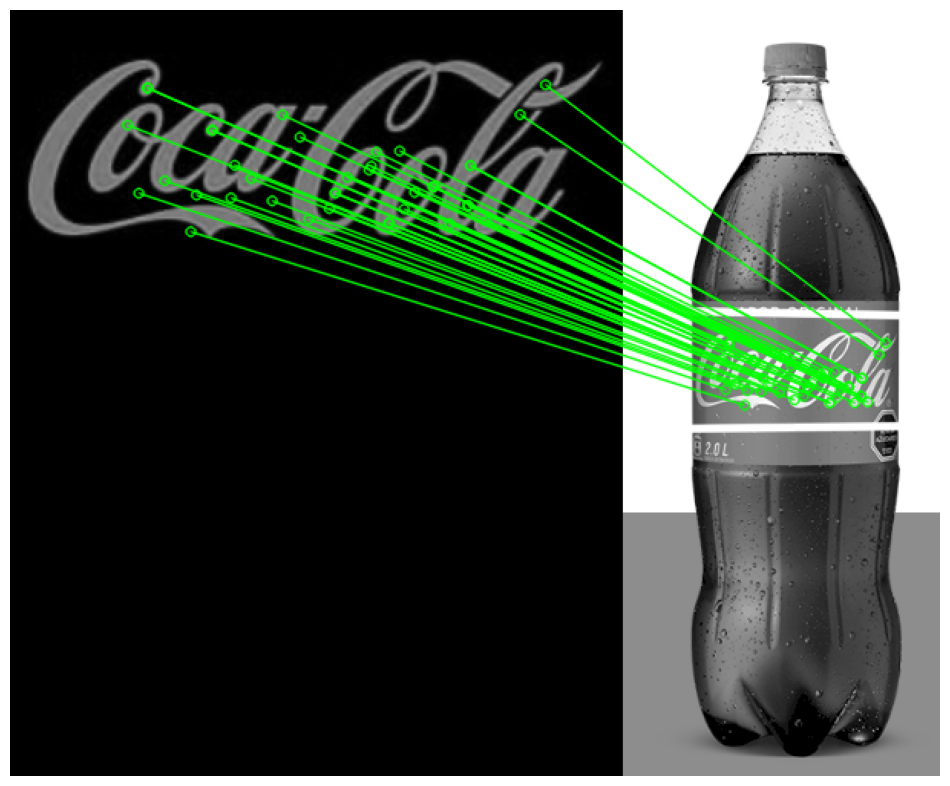

Procesando imagen: coca_logo_2.png
211
659
(211, 128)
(659, 128)
211
659
(211, 128)
(659, 128)
Cantidad de coincidencias buenas: 16
Cantidad de coincidencias buenas: 51
Usando template invertido para la imagen: coca_logo_2.png
Cantidad de coincidencias buenas: 51


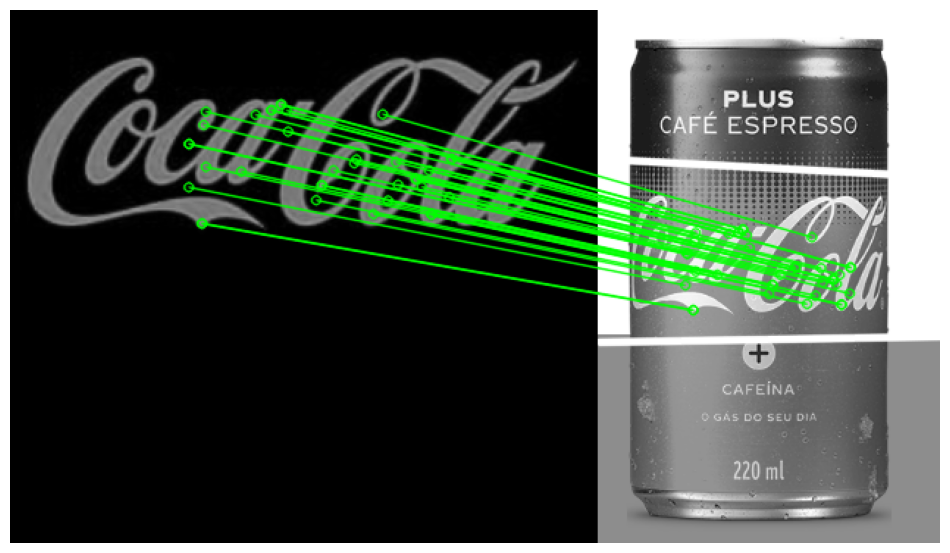

Procesando imagen: coca_retro_1.png
211
4196
(211, 128)
(4196, 128)
211
4196
(211, 128)
(4196, 128)
Cantidad de coincidencias buenas: 59
Cantidad de coincidencias buenas: 10
Usando template original para la imagen: coca_retro_1.png
Cantidad de coincidencias buenas: 59


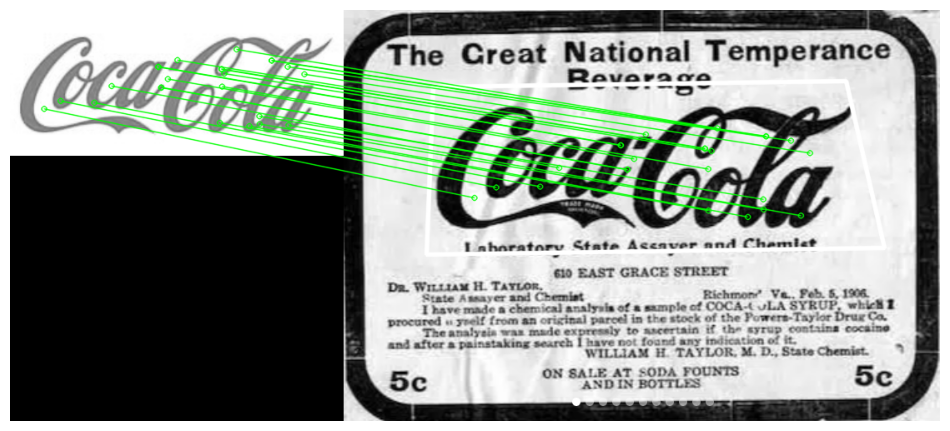

Procesando imagen: coca_retro_2.png
211
1480
(211, 128)
(1480, 128)
211
1480
(211, 128)
(1480, 128)
Cantidad de coincidencias buenas: 7
Cantidad de coincidencias buenas: 26
Usando template invertido para la imagen: coca_retro_2.png
Cantidad de coincidencias buenas: 26


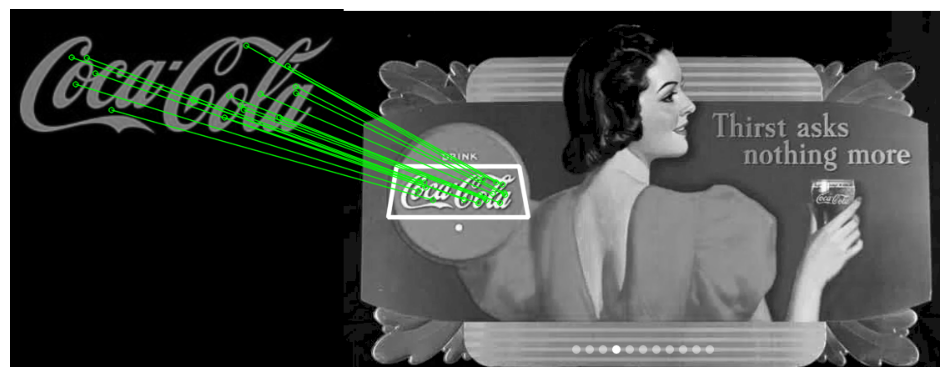

Procesando imagen: COCA-COLA-LOGO.jpg
211
2907
(211, 128)
(2907, 128)
211
2907
(211, 128)
(2907, 128)
Cantidad de coincidencias buenas: 23
Cantidad de coincidencias buenas: 61
Usando template invertido para la imagen: COCA-COLA-LOGO.jpg
Cantidad de coincidencias buenas: 61


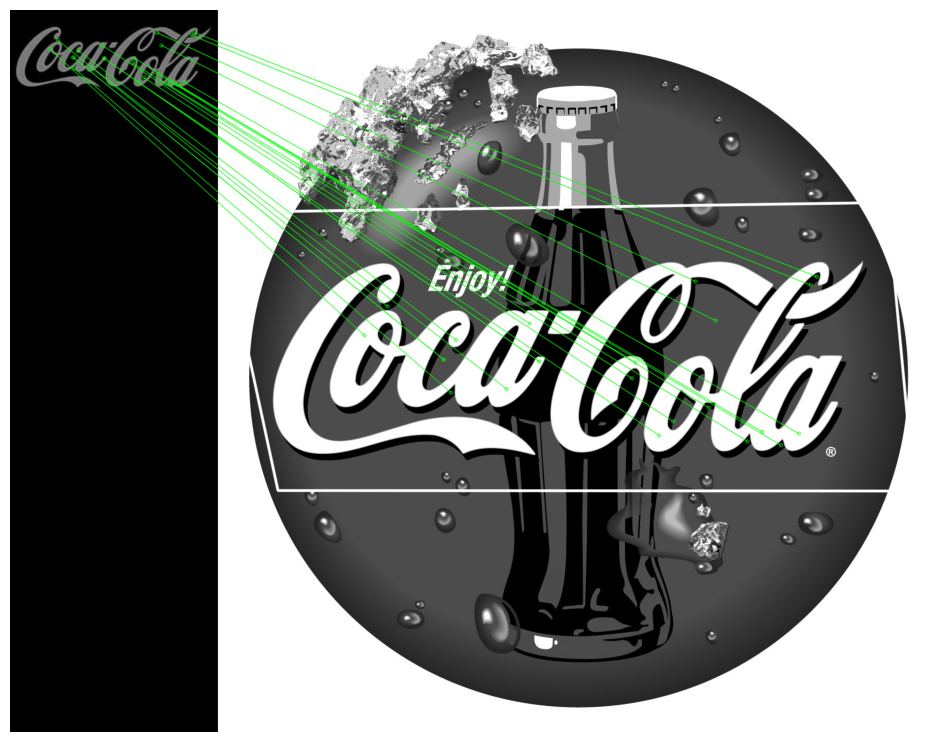

Procesando imagen: logo_1.png
211
589
(211, 128)
(589, 128)
211
589
(211, 128)
(589, 128)
Cantidad de coincidencias buenas: 10
Cantidad de coincidencias buenas: 66
Usando template invertido para la imagen: logo_1.png
Cantidad de coincidencias buenas: 66


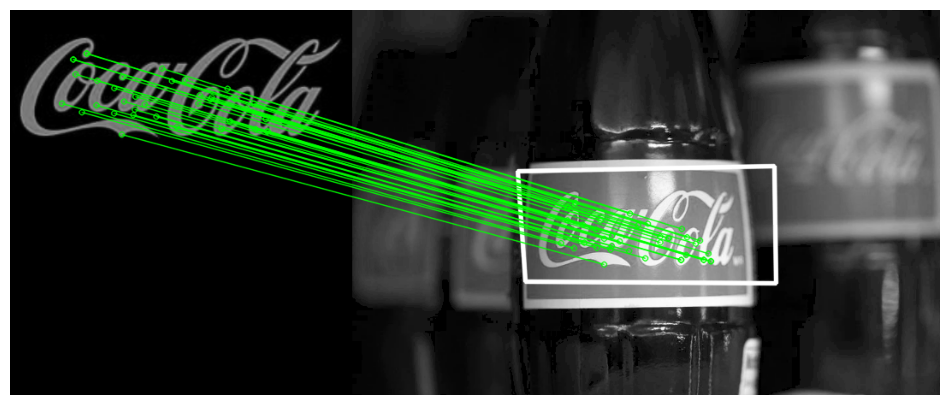

In [61]:
images = ["coca_logo_1.png", "coca_logo_2.png", "coca_retro_1.png", "coca_retro_2.png", "COCA-COLA-LOGO.jpg", "logo_1.png"]
for image_name in images:
    print(f"Procesando imagen: {image_name}")
    image_path = f"imagenes/{image_name}"
    img_gray = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    #evaluate_matches(template_gray_inverted, img_gray)
    matches_1, kp1_1, kp2_1 = match_flann_knn(template_gray, img_gray, sift, percent=0.8)
    matches_2, kp1_2, kp2_2 = match_flann_knn(template_gray_inverted, img_gray, sift, percent=0.8)
    print(f"Cantidad de coincidencias buenas: {len(matches_1)}")
    print(f"Cantidad de coincidencias buenas: {len(matches_2)}")
    if len(matches_1) > len(matches_2):
        print(f"Usando template original para la imagen: {image_name}")
        draw_matches_with_homography(template_gray, img_gray, kp1_1, kp2_1, matches_1)
    else:
        print(f"Usando template invertido para la imagen: {image_name}")
        draw_matches_with_homography(template_gray_inverted, img_gray, kp1_2, kp2_2, matches_2)

# * 2. (4 puntos) Plantear y validar un algoritmo para multiples detecciones en la imagen *coca_multi.png* con el mismo template del item 1.
Deteccion de multiples logos

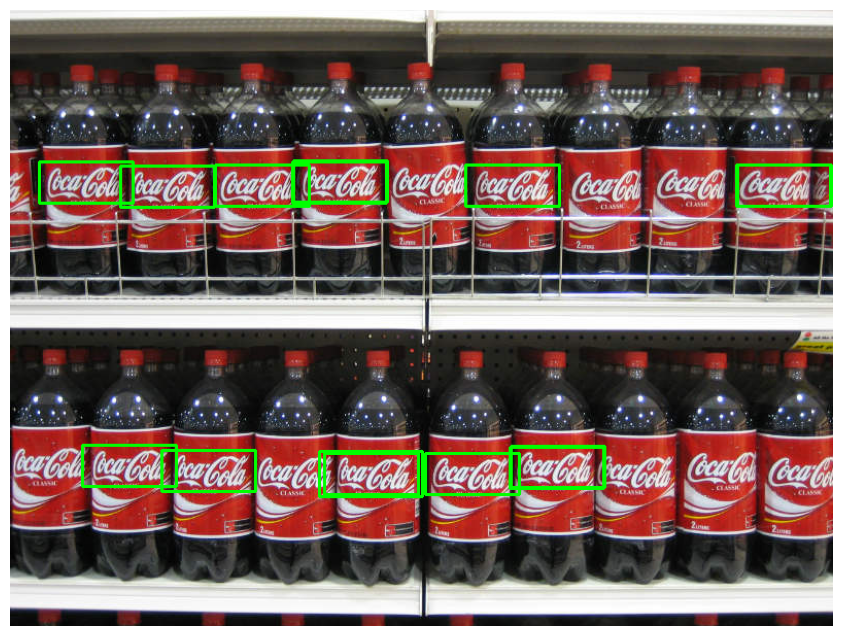

In [66]:
#Cargar imágenes
img = cv.imread('imagenes/coca_multi.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
template = cv.imread('template/pattern.png', cv.IMREAD_GRAYSCALE)
# Inverir las intensidades del template par que tenga mismo fondo que las etiquetas
template = cv.bitwise_not(template)
img_draw = img_rgb.copy()
threshold = 0.5
#Escalar el template ya que es muy grande para la imagen 
scales = np.linspace(0.1, 0.4, 15)

for scale in scales:
    resized_template = cv.resize(template, None, fx=scale, fy=scale)
    h_s, w_s = resized_template.shape[:2]

    if h_s > img_gray.shape[0] or w_s > img_gray.shape[1]:
        continue

    res = cv.matchTemplate(img_gray, resized_template, cv.TM_CCOEFF_NORMED)

    # Extraer progresivamente la coincidencia máxima y borrar la zona para evitar duplicados
    while True:
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
        
        if max_val < threshold:
            break  # No hay más coincidencias válidas en esta escala

        x, y = max_loc
        cv.rectangle(img_draw, (x, y), (x + w_s, y + h_s), (0, 255, 0), 2)

        # "Anular" el área encontrada en la matriz de resultados asignándole 0
        res[y : y + h_s, x : x + w_s] = 0

plt.figure(figsize=(12, 8))
plt.imshow(img_draw)
plt.axis('off')
plt.show()